In [6]:
import pandas as pd

#Loading the dataset
#In analysis:
df = pd.read_csv(r"C:\Users\mithu\OneDrive\Documents\ai-governance-shadow-ai\data\raw\ai_governance_shadow_ai.csv")
df.head()

,Employee_ID,Department,Role,AI_Tool_Used,Approved_Tool,Usage_Frequency,Data_Type_Used,Sensitivity_Level,Policy_Aware,Approval_Requested,Risk_Level,Region,Date
0,E001,Finance,Analyst,ChatGPT,No,Daily,Financial Reports,High,Yes,No,High,APAC,2025-01-15
1,E002,Marketing,Manager,Copy.ai,Yes,Weekly,Campaign Content,Low,Yes,Yes,Low,EMEA,2025-01-18
2,E003,HR,Recruiter,ChatGPT,No,Daily,Resumes,Medium,No,No,High,APAC,2025-02-01
3,E004,Engineering,Developer,Github Copilot,Yes,Daily,Source Code,Medium,Yes,Yes,Medium,NaN,2025-02-10
4,E005,Sales,Executive,Claude,No,Weekly,Client Data,High,No,No,High,EMEA,2025-02-14


In [5]:
#Loading the dataset
#Checking dataset:

df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         15 non-null     object
 1   Department          15 non-null     object
 2   Role                15 non-null     object
 3   AI_Tool_Used        15 non-null     object
 4   Approved_Tool       15 non-null     object
 5   Usage_Frequency     15 non-null     object
 6   Data_Type_Used      15 non-null     object
 7   Sensitivity_Level   15 non-null     object
 8   Policy_Aware        15 non-null     object
 9   Approval_Requested  15 non-null     object
 10  Risk_Level          15 non-null     object
 11  Region              10 non-null     object
 12  Date                15 non-null     object
dtypes: object(13)
memory usage: 1.7+ KB


In [8]:
#Data cleaning
#Checking nulls:

df.isnull().sum()

Employee_ID           0
Department            0
Role                  0
AI_Tool_Used          0
Approved_Tool         0
Usage_Frequency       0
Data_Type_Used        0
Sensitivity_Level     0
Policy_Aware          0
Approval_Requested    0
Risk_Level            0
Region                5
Date                  0
dtype: int64

In [10]:
#Data cleaning
#Remove duplicates:

df = df.drop_duplicates()

In [11]:
#Data cleaning
#Handle missing values if any:

df = df.dropna()

In [15]:
#Data cleaning
#Save cleaned data:

df.to_csv(r"C:\Users\mithu\OneDrive\Documents\ai-governance-shadow-ai\data\raw\ai_governance_shadow_ai.csv", index=False)

In [16]:
#Feature engineering
#Creating Shadow AI column:
df['Shadow_AI'] = df['Approved_Tool'] == 'No'

In [17]:
#Feature engineering
#Creating numeric risk:

risk_map = {
    'Low':1,
    'Medium':2,
    'High':3
}

df['Risk_Score'] = df['Risk_Level'].map(risk_map)

In [18]:
#Exploratory Data Analysis (EDA)
#Shadow AI %

shadow_rate = df['Shadow_AI'].mean() * 100
print(shadow_rate)

60.0


In [19]:
#Exploratory Data Analysis (EDA)
#Risk count

df['Risk_Level'].value_counts()

Risk_Level
High      4
Low       4
Medium    2
Name: count, dtype: int64

In [20]:
#Exploratory Data Analysis (EDA)
#Department analysis

df.groupby('Department')['Shadow_AI'].mean()

Department
Finance       1.0
HR            1.0
Legal         1.0
Marketing     0.5
Operations    0.0
Sales         0.5
Name: Shadow_AI, dtype: float64

In [21]:
#Exploratory Data Analysis (EDA)
#High-risk exposure

high_risk = df[
    (df['Shadow_AI']) &
    (df['Sensitivity_Level'] == 'High')
]
high_risk

,Employee_ID,Department,Role,AI_Tool_Used,Approved_Tool,Usage_Frequency,Data_Type_Used,Sensitivity_Level,Policy_Aware,Approval_Requested,Risk_Level,Region,Date,Shadow_AI,Risk_Score
0,E001,Finance,Analyst,ChatGPT,No,Daily,Financial Reports,High,Yes,No,High,APAC,2025-01-15,True,3
4,E005,Sales,Executive,Claude,No,Weekly,Client Data,High,No,No,High,EMEA,2025-02-14,True,3
10,E011,HR,Manager,ChatGPT,No,Weekly,Employee Records,High,No,No,High,APAC,2025-03-18,True,3


In [22]:
#Exploratory Data Analysis (EDA)
#Policy gap

df.groupby('Policy_Aware')['Shadow_AI'].mean()

Policy_Aware
No     1.000000
Yes    0.428571
Name: Shadow_AI, dtype: float64

In [23]:
#Visualization

import matplotlib.pyplot as plt

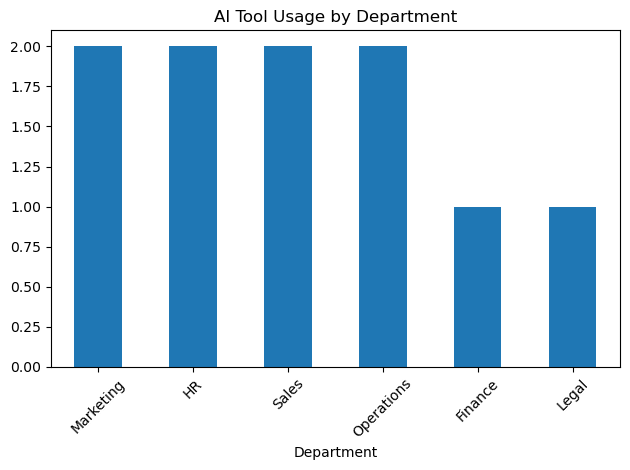

In [26]:
#Visualization
#Chart 1

df['Department'].value_counts().plot(kind='bar')
plt.title("AI Tool Usage by Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\mithu\OneDrive\Documents\ai-governance-shadow-ai\outputs\charts\department_usage.png")
plt.show()

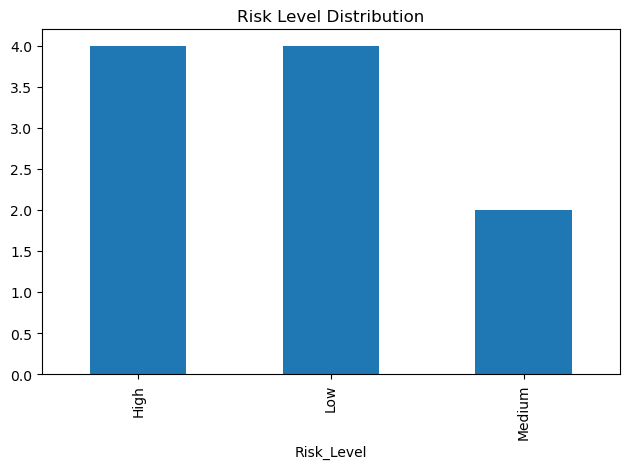

In [27]:
#Visualization
#Chart 2

df['Risk_Level'].value_counts().plot(kind='bar')
plt.title("Risk Level Distribution")
plt.tight_layout()
plt.savefig(r"C:\Users\mithu\OneDrive\Documents\ai-governance-shadow-ai\outputs\charts\risk_distribution.png")
plt.show()

In [28]:
#Creating reusable scripts

#Inside src/
#data_cleaning.py

import pandas as pd

def load_data(path):
    return pd.read_csv(path)

def clean_data(df):
    df = df.drop_duplicates()
    df = df.dropna()
    return df

In [29]:
#Creating reusable scripts

#Inside src/
#feature_engineering.py

def create_shadow_ai(df):
    df['Shadow_AI'] = df['Approved_Tool'] == 'No'
    return df

def create_risk_score(df):
    risk = {'Low':1, 'Medium':2, 'High':3}
    df['Risk_Score'] = df['Risk_Level'].map(risk)
    return df

In [30]:
#Creating reusable scripts

#Inside src/
#analysis.py

def shadow_rate(df):
    return df['Shadow_AI'].mean() * 100

#The notebook can call these instead of rewriting logic